In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
data = {
    'Age': [19, 21, 20, 23, 31, 22, 35, 23, 64, 30,
            67, 35, 58, 24, 37, 22, 35, 20, 52, 35],

    'Annual_Income': [15, 15, 16, 16, 17, 17, 18, 18, 19, 19,
                      20, 20, 21, 21, 22, 22, 23, 23, 24, 24],

    'Spending_Score': [39, 81, 6, 77, 40, 76, 6, 94, 3, 72,
                       14, 99, 15, 77, 13, 79, 35, 66, 29, 98]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)


Dataset:
    Age  Annual_Income  Spending_Score
0    19             15              39
1    21             15              81
2    20             16               6
3    23             16              77
4    31             17              40
5    22             17              76
6    35             18               6
7    23             18              94
8    64             19               3
9    30             19              72
10   67             20              14
11   35             20              99
12   58             21              15
13   24             21              77
14   37             22              13
15   22             22              79
16   35             23              35
17   20             23              66
18   52             24              29
19   35             24              98


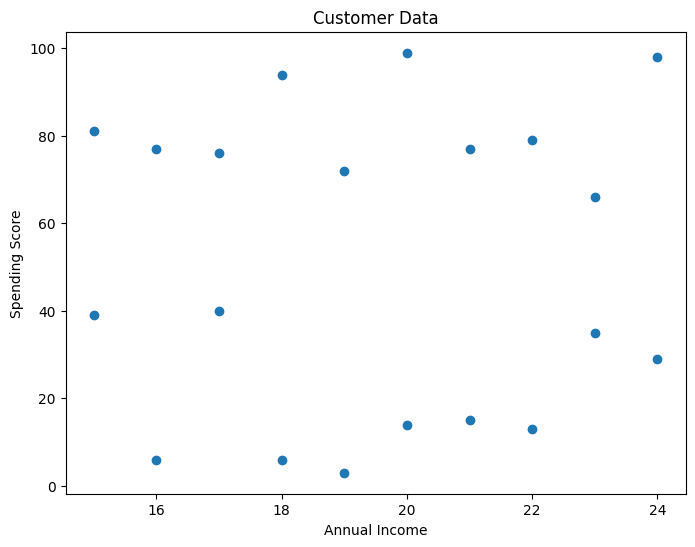

In [4]:
plt.figure(figsize=(8,6))
plt.scatter(df['Annual_Income'], df['Spending_Score'])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Data')
plt.show()



In [5]:
X = df[['Annual_Income', 'Spending_Score']]


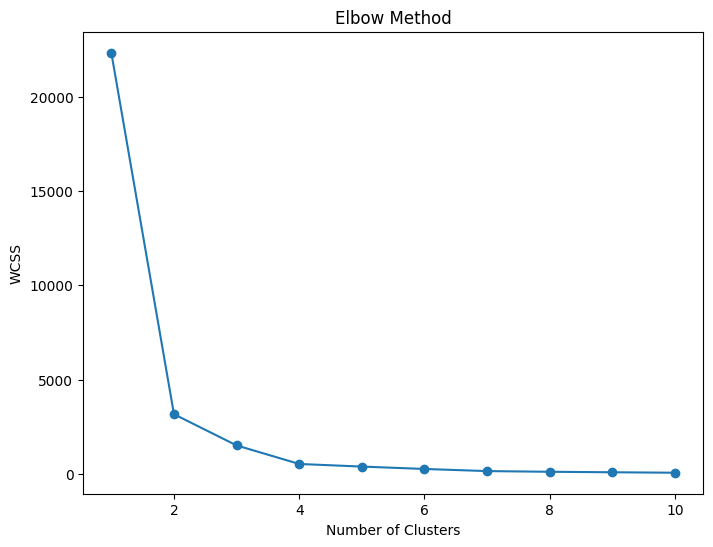

In [6]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

print("\nClustered Data:")
print(df)




Clustered Data:
    Age  Annual_Income  Spending_Score  Cluster
0    19             15              39        2
1    21             15              81        0
2    20             16               6        1
3    23             16              77        0
4    31             17              40        2
5    22             17              76        0
6    35             18               6        1
7    23             18              94        0
8    64             19               3        1
9    30             19              72        0
10   67             20              14        1
11   35             20              99        0
12   58             21              15        1
13   24             21              77        0
14   37             22              13        1
15   22             22              79        0
16   35             23              35        2
17   20             23              66        0
18   52             24              29        2
19   35             24 

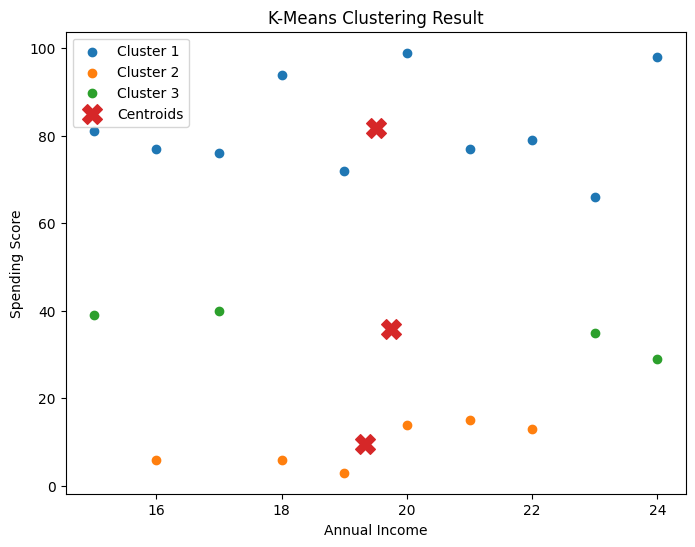

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(df[df['Cluster'] == 0]['Annual_Income'],
            df[df['Cluster'] == 0]['Spending_Score'],
            label='Cluster 1')

plt.scatter(df[df['Cluster'] == 1]['Annual_Income'],
            df[df['Cluster'] == 1]['Spending_Score'],
            label='Cluster 2')

plt.scatter(df[df['Cluster'] == 2]['Annual_Income'],
            df[df['Cluster'] == 2]['Spending_Score'],
            label='Cluster 3')

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X', label='Centroids')

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('K-Means Clustering Result')
plt.legend()
plt.show()